# Week 5 Retrospective Acquisition-Function Analysis — Function_01

**RETROSPECTIVE, COUNTERFACTUAL, AND UNEVALUATED.** This notebook computes what an acquisition function would have recommended using only the data available at the start of Historical_Replay Week_05. This point was **NEVER actually queried**, has **NO associated real output**, was **NEVER submitted anywhere**, and is **NOT part of this project's genuine historical or live-submission data**.

**Track:** Historical_Replay, Week_05 only. This is a *what-if* analysis
answering: "given only the data chronologically available at the start of
Week_05, what would Expected Improvement (EI), Upper Confidence Bound (UCB),
and Probability of Improvement (PI) each have recommended as the next query
point?"

This notebook is physically separate from, and does not modify,
`../01_Notebook/week_05_gp_diagnostics.ipynb` (the verified GP diagnostics
notebook for this function/week). It performs a **fresh, independent GP
refit** using the same data, kernel construction, and seed convention as
that notebook, purely to compute acquisition-function values that the
diagnostics notebook explicitly never computed.

No query proposed here was ever submitted. No `03_Queries` folder is
referenced or created. No cumulative dataset is modified. No data from
Week_02, Week_03, Week_04, or Week_06 is used or referenced anywhere in this
notebook.


## 1. Data boundary and chronological validity

The only data used anywhere in this notebook is Function_01's own:

- `../02_Data/cumulative_inputs.npy`
- `../02_Data/cumulative_outputs.npy`

These are the exact same two files already used (read-only) by
`../01_Notebook/week_05_gp_diagnostics.ipynb` for this function/week — i.e.
exactly the data chronologically available at the start of Historical_Replay
Week_05, with **no lookahead**. Expected shape for Function_01:
`n=14` rows, `d=2` columns (official bounds `[0.000000, 0.999999]`,
maximisation problem, per CLAUDE.md rules 16–17).

**Step-1 kernel-selection outcome for this function** (independently
confirmed against `../../CODE_REVIEW_SUMMARY.md` and this function's own
executed `week_05_gp_diagnostics.ipynb`):

> Selected kernel: **RBF**. Both kernels converged cleanly (0/6 ABNORMAL each); RBF selected on higher LML.


In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
import matplotlib.pyplot as plt
import os

FUNCTION_NUMBER = 1
N_EXPECTED = 14
D_EXPECTED = 2
LOWER_BOUND, UPPER_BOUND = 0.000000, 0.999999
SEED = 42 + FUNCTION_NUMBER  # same seed convention as every other Week_05 notebook
ACQ_SEED = 5000 + 42 + FUNCTION_NUMBER  # Week_05-specific acquisition-optimizer seed offset (5000)
print("FUNCTION_NUMBER:", FUNCTION_NUMBER)
print("GP random_state (SEED):", SEED)
print("Acquisition multi-start seed (ACQ_SEED):", ACQ_SEED)

os.makedirs("figures", exist_ok=True)


FUNCTION_NUMBER: 1
GP random_state (SEED): 43
Acquisition multi-start seed (ACQ_SEED): 5043


In [2]:
# Load ONLY this function's own Week_05 cumulative data (no lookahead).
X = np.load("../02_Data/cumulative_inputs.npy")
y = np.load("../02_Data/cumulative_outputs.npy")

assert X.shape == (N_EXPECTED, D_EXPECTED), f"unexpected input shape {X.shape}"
assert y.shape == (N_EXPECTED,), f"unexpected output shape {y.shape}"
assert np.isfinite(X).all() and np.isfinite(y).all(), "non-finite values found"
assert X.min() >= LOWER_BOUND and X.max() <= UPPER_BOUND, "input out of official bounds"

X_rounded = np.round(X, 6)
n_unique = len(np.unique(X_rounded, axis=0))
print("Loaded X shape:", X.shape, " y shape:", y.shape)
print("Bounds check passed: [", X.min(), ",", X.max(), "] within [0, 0.999999]")
print("Unique rows (rounded to 6 dp):", n_unique, "/", X.shape[0],
      "(duplicates are informational only, not an error)")


Loaded X shape: (14, 2)  y shape: (14,)
Bounds check passed: [ 0.07872277794971883 , 0.950714 ] within [0, 0.999999]
Unique rows (rounded to 6 dp): 14 / 14 (duplicates are informational only, not an error)


## 2. Standardisation and fresh GP refit

`y` is standardised (zero mean, unit variance) before fitting, exactly as in
every other notebook in this project, and every posterior quantity is
inverse-transformed back to the raw output scale before any acquisition
value is computed (acquisition functions must operate on real, raw output
units since the recommended points and `f_best` are compared in that scale).

Kernel construction (identical to every Week_05 notebook):

```
ConstantKernel(1.0, (1e-2, 1e2)) * (RBF | Matern(nu=2.5, length_scale_bounds=(1e-2,1e2)))
    + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))
GaussianProcessRegressor(alpha=1e-10, n_restarts_optimizer=5, normalize_y=False, random_state=SEED)
```

This is a **fresh, independent refit** performed inside this new notebook —
it does not read or reuse any fitted model object from
`../01_Notebook/week_05_gp_diagnostics.ipynb`.


In [3]:
y_mean = y.mean()
y_std = y.std(ddof=0) or 1.0
y_scaled = (y - y_mean) / y_std

def inverse_mean(m):
    return m * y_std + y_mean

def inverse_std(s):
    return s * y_std

def build_kernel(name, d):
    base = RBF(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2)) if name == "rbf" \
        else Matern(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2), nu=2.5)
    return ConstantKernel(1.0, (1e-2, 1e2)) * base + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))

def fit_gpr(name, d, seed):
    gpr = GaussianProcessRegressor(kernel=build_kernel(name, d), alpha=1e-10,
                                    n_restarts_optimizer=5, normalize_y=False,
                                    random_state=seed)
    gpr.fit(X, y_scaled)
    return gpr

fitted_models = {}
for kname in ['rbf']:
    gpr_k = fit_gpr(kname, D_EXPECTED, SEED)
    fitted_models[kname] = gpr_k
    print(f"Fitted {kname.upper()} | kernel: {gpr_k.kernel_}")
    print(f"  log-marginal-likelihood (standardised y): {gpr_k.log_marginal_likelihood_value_:.4f}")


Fitted RBF | kernel: 1.05**2 * RBF(length_scale=[100, 0.0312]) + WhiteKernel(noise_level=2.04e-09)
  log-marginal-likelihood (standardised y): -18.0664


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 3. Acquisition-function formulas (documented parameters)

All formulas operate in the **raw output scale** (posterior mean/std are
inverse-transformed first), and all are oriented for **maximisation**
(CLAUDE.md rule 17). `f_best` is this function's own best-observed raw
output within its Week_05 cumulative data (no lookahead).

- **Expected Improvement (EI)**, `xi = 0.01` (raw output units):
  `improvement(x) = mu(x) - f_best - xi`
  `z(x) = improvement(x) / sigma(x)` (defined as `0` if `sigma(x) == 0`)
  `EI(x) = improvement(x) * Phi(z(x)) + sigma(x) * phi(z(x))` if `sigma(x) > 0`, else `0`

- **Upper Confidence Bound (UCB)**, `kappa = 2.0`:
  `UCB(x) = mu(x) + kappa * sigma(x)`

- **Probability of Improvement (PI)**, same `z(x)`/`xi` as EI:
  `PI(x) = Phi(z(x))`

`Phi` is the standard normal CDF, `phi` the standard normal PDF
(`scipy.stats.norm`). These are exploration/exploitation trade-off functions
in the classical BO sense (CLAUDE.md rule 5): EI and PI trade off predicted
improvement over `f_best` against uncertainty via `xi`; UCB trades off mean
against uncertainty directly via `kappa`, with no explicit best-so-far term.


In [4]:
XI = 0.01
KAPPA = 2.0

def gp_predict_raw(gpr, Xq):
    mu_s, sigma_s = gpr.predict(Xq, return_std=True)
    return inverse_mean(mu_s), inverse_std(sigma_s)

def acquisitions_raw(gpr, Xq, f_best):
    mu, sigma = gp_predict_raw(gpr, Xq)
    sigma_safe = np.where(sigma > 0, sigma, 1.0)
    improvement = mu - f_best - XI
    z = np.where(sigma > 0, improvement / sigma_safe, 0.0)
    ei = np.where(sigma > 0, improvement * norm.cdf(z) + sigma * norm.pdf(z), 0.0)
    ucb = mu + KAPPA * sigma
    pi = norm.cdf(z)
    return {"EI": ei, "UCB": ucb, "PI": pi, "mu": mu, "sigma": sigma}

f_best = float(y.max())
best_idx = int(np.argmax(y))
print("f_best (own Week_05 cumulative best-observed output, raw scale):", f_best)
print("Achieved at own cumulative-data row index:", best_idx,
      "input:", np.round(X[best_idx], 6))


f_best (own Week_05 cumulative best-observed output, raw scale): 7.710875114502849e-16
Achieved at own cumulative-data row index: 2 input: [0.731024 0.733   ]


## 4. Maximising each acquisition function (fine grid, d=2)

This function has d=2, so each acquisition function is maximised by
evaluating it on a fine regular grid over `[0.000000, 0.999999]^2` and
taking the arg-max (no gradient-based optimizer needed at this
dimensionality).

In [5]:
GRID_N = 401  # 401x401 fine grid over [0, 0.999999]^2
grid_1d = np.linspace(LOWER_BOUND, UPPER_BOUND, GRID_N)
GX, GY = np.meshgrid(grid_1d, grid_1d)
grid_points = np.column_stack([GX.ravel(), GY.ravel()])
print("Grid points evaluated per kernel:", grid_points.shape[0])

def optimise_grid(gpr, f_best):
    acq = acquisitions_raw(gpr, grid_points, f_best)
    results = {}
    for name in ["EI", "UCB", "PI"]:
        idx = int(np.argmax(acq[name]))
        results[name] = dict(x=grid_points[idx].copy(), value=float(acq[name][idx]))
    return results, acq

grid_results = {}
grid_acq_full = {}
for kname, gpr_k in fitted_models.items():
    res, acq_full = optimise_grid(gpr_k, f_best)
    grid_results[kname] = res
    grid_acq_full[kname] = acq_full
    for aname, r in res.items():
        print(f"[{kname.upper()}] {aname} argmax: x={np.round(r['x'],6)}  value={r['value']:.6f}")


Grid points evaluated per kernel: 160801
[RBF] EI argmax: x=[0.507499 0.495   ]  value=0.000000
[RBF] UCB argmax: x=[0.797499 0.519999]  value=0.001715
[RBF] PI argmax: x=[0.509999 0.495   ]  value=0.000000


## 5. Recommended points (submission-format string) and agreement check

Coordinates are rounded to exactly six decimal places and clamped to
`[0.000000, 0.999999]` (never `1.000000`), and formatted with the project's
official hyphen-separated, leading-zero, six-decimal submission convention
(CLAUDE.md rule 19) — for reporting/illustration only, since **none of these
points was ever submitted anywhere**.

In [6]:
def format_point(x):
    x = np.clip(np.round(x, 6), LOWER_BOUND, UPPER_BOUND)
    return "-".join(f"{v:.6f}" for v in x)

print(f"{'Kernel':<8}{'Acq':<6}{'Recommended point (hypothetical, unevaluated)':<60}{'Value':>12}")
formatted = {}
for kname, res in grid_results.items():
    formatted[kname] = {}
    for aname, r in res.items():
        s = format_point(r["x"])
        formatted[kname][aname] = s
        print(f"{kname.upper():<8}{aname:<6}{s:<60}{r['value']:>12.6f}")


Kernel  Acq   Recommended point (hypothetical, unevaluated)                      Value
RBF     EI    0.507499-0.495000                                               0.000000
RBF     UCB   0.797499-0.519999                                               0.001715
RBF     PI    0.509999-0.495000                                               0.000000


In [7]:
# Agreement check: pairwise Euclidean distance between EI/UCB/PI recommended
# points, computed separately for each kernel fitted above.
names = ["EI", "UCB", "PI"]
for kname, res in grid_results.items():
    print(f"Kernel: {kname.upper()}")
    pts = {name: res[name]["x"] for name in names}
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            dist = float(np.linalg.norm(pts[a] - pts[b]))
            print(f"  distance({a}, {b}) = {dist:.6f}")


Kernel: RBF
  distance(EI, UCB) = 0.291075
  distance(EI, PI) = 0.002500
  distance(UCB, PI) = 0.288585


**Interpretation guidance (to be filled by reading the printed distances
above):** small pairwise distances (relative to the `[0, 0.999999]` input
range) indicate the three acquisition functions agree on a similar region of
the input space for this function's data at the start of Week_05; large
distances indicate genuine divergence (e.g. EI/PI favouring
exploitation near the current best while UCB favours a more uncertain,
under-explored region, or vice versa depending on kernel length-scales).
This is a descriptive, retrospective observation only — it does not
validate or invalidate any acquisition function in general.

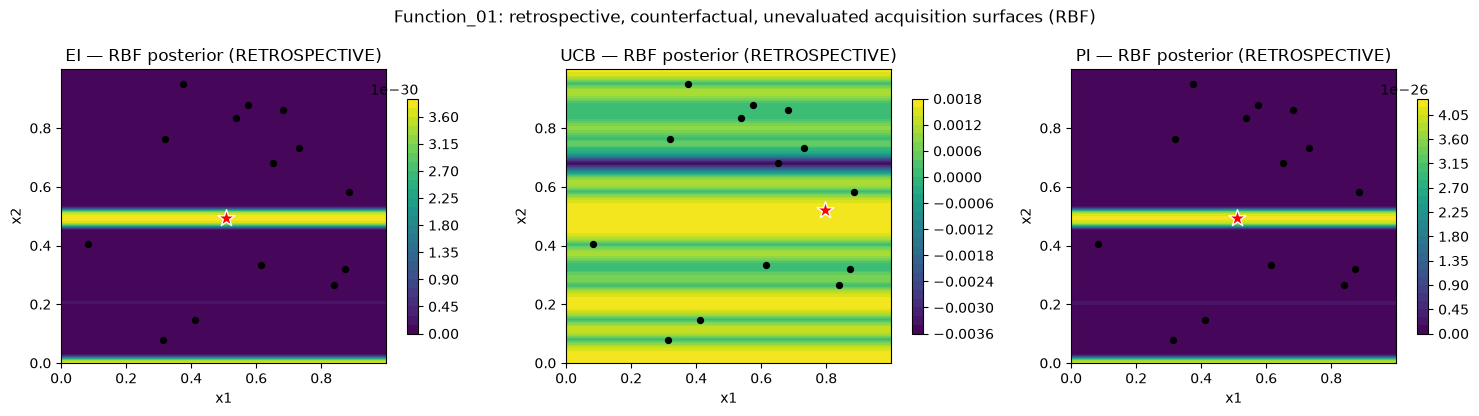

In [8]:
for kname in ['rbf']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, aname in zip(axes, ["EI", "UCB", "PI"]):
        Z = grid_acq_full[kname][aname].reshape(GRID_N, GRID_N)
        cf = ax.contourf(GX, GY, Z, levels=30, cmap="viridis")
        fig.colorbar(cf, ax=ax, shrink=0.8)
        rx = grid_results[kname][aname]["x"]
        ax.scatter(*rx, color="red", marker="*", s=160, edgecolor="white",
                   label="recommended (hypothetical)")
        ax.scatter(X[:, 0], X[:, 1], color="black", s=18, marker="o",
                   label="observed (Week_05 data)")
        ax.set_title(f"{aname} — {kname.upper()} posterior (RETROSPECTIVE)")
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
    fig.suptitle(f"Function_01: retrospective, counterfactual, unevaluated acquisition surfaces ({kname.upper()})")
    fig.tight_layout()
    fig.savefig(f"figures/retrospective_acquisition_surfaces_{kname}.png", dpi=140, bbox_inches="tight")
    plt.show()


## 6. Scope, limitations, and repeated disclaimer

**RETROSPECTIVE, COUNTERFACTUAL, AND UNEVALUATED.** This notebook computes what an acquisition function would have recommended using only the data available at the start of Historical_Replay Week_05. This point was **NEVER actually queried**, has **NO associated real output**, was **NEVER submitted anywhere**, and is **NOT part of this project's genuine historical or live-submission data**.

- No acquisition value or recommended point on this page was ever queried,
  submitted, or compared against any genuine historical output for
  Function_01 or any other function.
- No `03_Queries` folder is referenced or created by this notebook.
- No cumulative dataset (`cumulative_inputs.npy` / `cumulative_outputs.npy`)
  is modified anywhere in this notebook — both are loaded read-only.
- No data or file from Week_02, Week_03, Week_04, or Week_06 is used or
  referenced anywhere in this notebook.
- `EI`/`UCB`/`PI` are standard, well-understood acquisition-function forms;
  they are being computed here for the first time in this project purely as
  a retrospective exercise, since every prior GP-diagnostics notebook in
  this project explicitly stopped before proposing any query.
